# **Learning Latent strengths with Bradley-Terry Model**

## 1. Cleaning Dataset

Our main dataset came from an internet website "". The first step is to check if there is missing values or any problem with the data.

In [ ]:
from Data.data_cleaning import Datacleaner

cleaner = Datacleaner("./Data/Datasets/ligue1_2010_2025.csv")

cleaner = (cleaner.drop_useless_columns()
           .drop_rows(row_idxs=[1520,2281])
           .fillNA(column='Div',value='F1')
           .fillNA(column='Time', value='00:00')
           .add_season())

# Save clean dataframe
cleaner.save_data("Data/Datasets/Match_dataset_clean.csv")

Next we prepare the dataset for the analysis. Two main things are done during this step :
- **Feature Engineering** : Adding new team variables by aggregating matches data
- **Merge** : Merging the main match dataset with an additional market value dataset (Data/Datasets/ligue1_market_values_2010_2025.csv, obtained from script Data/ScrapingMarketValue.py)

In [ ]:
from Data.data_preparing import DataPreparer

preparer = DataPreparer(match_data_filepath="Data/Datasets/Match_dataset_clean.csv",
                        market_value_filepath="Data/Datasets/ligue1_market_values_2010_2025.csv")

# Save Features DataFrame
preparer.feature_engineering(save=True, display=False)

# Save the final complete DataFrame
df = preparer.merge_df(save=True)

Then we process the data for the main analysis. Data are split into train and test set. Since our data consists of soccer matches, the separation is temporal. We use the 2010-2011 to 2023-24 seasons for training and the 2024-2025 season for testing.

From now on, we will refer to the “classical” probabilistic model as BT and the neural network as NBTR.

In [1]:
from Data.data_processing import DataProcesser

processer = DataProcesser("Data/Datasets/Complete_df.csv")

# Splitted Dataframes
train_df, test_df = processer.split_train_test(test_season='24-25')

# Processing Data for BT model
train_data_BT, test_data = processer.get_train_test_data_BT()

# Processing Data for NBTR model
feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

train_data_NBTR = processer.get_data_NBTR(feature_names=feature_names)

## 2. Probabilistic Bradley-Terry Model

We start by calibrating the hyperparameter $\lambda$ that describes the propensity for ties. Since we consider it as a parameter of the sport rather than dependent on teams or seasons, we calibrate it before training the model by choosing the value that maximizes the log-likelihood of the model over the whole training set.

In [ ]:
from BradleyTerry_classical.functions import BT_calibrate
import numpy as np

# Calibrate Hyperparameter Lambda
Lambda_Chooser = BT_calibrate(train_data=train_data_BT)

lambda_grid = np.linspace(-3,2,30)

Lambda_Chooser.calibrate_lambda(lambda_grid=lambda_grid)

According to this figure, the optimal value for $\lambda$ is $\lambda^* = 0,24$. We use this value for the training.

In [6]:
from BradleyTerry_classical.BT_classical import BradleyTerry

# Train the model
bt_model = BradleyTerry(lambda_draw=-0.24, learning_rate=0.01, n_iterations=1000)
bt_model.fit(train_data=train_data_BT)

# Vector of strengths (DataFrame)
BT_strength = bt_model.predict_strength()

# Outcomes probabilities for each match on the test set (DataFrame)
BT_probas = bt_model.simulate_season(list_teams=test_data['Teams'])

Tolerance threshold attained after 333 iterations
Model fitted successfully !


## 3. Neural Bradley-Terry Model

Now we focus on the Neural version of the model. Here too, the first step is to calibrate the hyperparameters. Unlike the BT model, the training data is separated into a training set and a validation set. The 2010-2011 to 2022-2023 seasons are used for training, and the 2023-24 season is used for validation. To save time, the models are trained on fewer epochs.

In [2]:
from Neural_Bradley_Terry.calibrate import NBTR_calibrate
import numpy as np

calibrator = NBTR_calibrate(train_data_filepath='Data/Datasets/Complete_df.csv')

In [ ]:
# Grid on the number of layer and learning rate
hidden_dims = [8, 16, 32, 64]
lrs = [0.001, 0.005, 0.01, 0.05]

best_hd, best_lr, min_loss = calibrator.calibrate_hyperparams(hidden_dims, lrs)
print(f"Optimal hidden_dim: {best_hd}, Optimal lr: {best_lr}, Minimum BCE Loss: {min_loss}")

According to the previous code, optimal values are $16$ for the number of layers and $0,001$ for the learning rate. We use them for the final training of the model

We now aim at calibrating the draw parameter of the NBTR. It is not properly a parameter of the model but more something like a heuristic used when computing probas from estimated strengths. To calibrate it we minimise a weighted log-Loss in order to be more realistic with draws. Chosen weigths are inverse frequency of each class in the evaluation set.

Training model...
Inverse frequency weights: {'A': np.float64(0.9714285714285714), 'D': np.float64(1.2592592592592593), 'H': np.float64(0.85)}


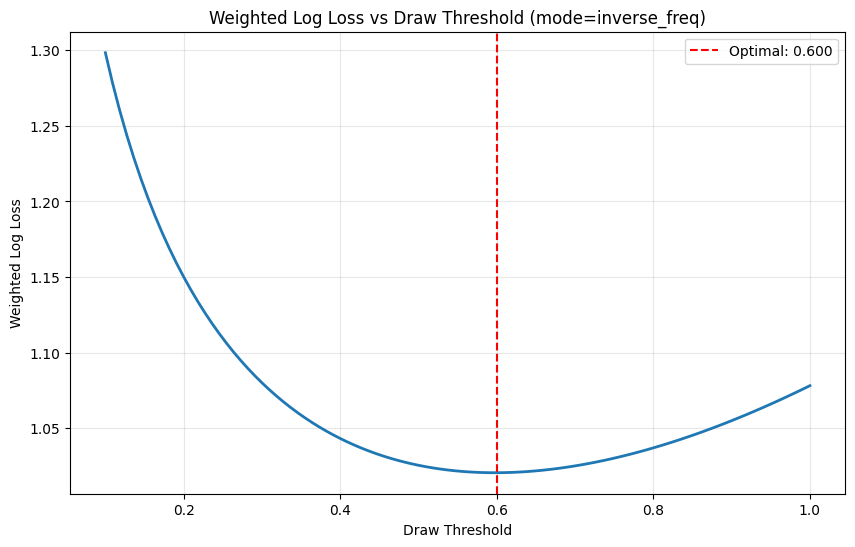

Best draw_threshold: 0.600 with loss: 1.0206


In [3]:
# Draw threshold
draw_thresholds = np.linspace(0.1,1,100)

best_dt, min_loss_dt = calibrator.calibrate_draw_threshold(draw_thresholds= draw_thresholds, weight_mode='inverse_freq')

According to this figure, the optimal threshold is $0.600$. We will use it for the training.

In [4]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry

NBTR_model = NeuralBradleyTerry(input_dim=train_data_NBTR['input_dim'], hidden_dim=16, lr=0.001)

NBTR_model.fit(train_data_NBTR['X_home'], train_data_NBTR['X_away'], train_data_NBTR['y'], epochs=500)

# Vector of strengths (DataFrame)
NBTR_strength = NBTR_model.get_season_ranking(test_df=test_df, feature_cols=feature_names)

#Outcomes probabilities for each match on the test set (DataFrame)
NBTR_probas = NBTR_model.predict_season_probas(test_df=test_df, feature_cols=feature_names, draw_threshold=0.600)

## 4. Comparing Models

Now that we've collected outcomes of both models, we aim at comparing them. There is different scale for which the comparison is worth making :

- **Team Level** : We want to compare the global ranking of each model. To this extent we focus on vector of strengths and its correlation with the other model or with empirical data.

- **Match Level** : We want to compare the prediction of each match with the true result. To this extent we focus on the estimated probabilities given by each model.

- **Stability Analysis** : Here we seek to measure the effect of random initialization of the neural network on the results. We run the NBTR model multiple times and look at the variances of outcomes.

#### 4.1 Team Level Comparison

In [7]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate = BT_evaluate_strengths(BT_results=BT_strength, NBTR_results=NBTR_strength, test_df=test_df)

We first plot the strength distribution given by each model and a scatter plot to visualize where the rankings differ.

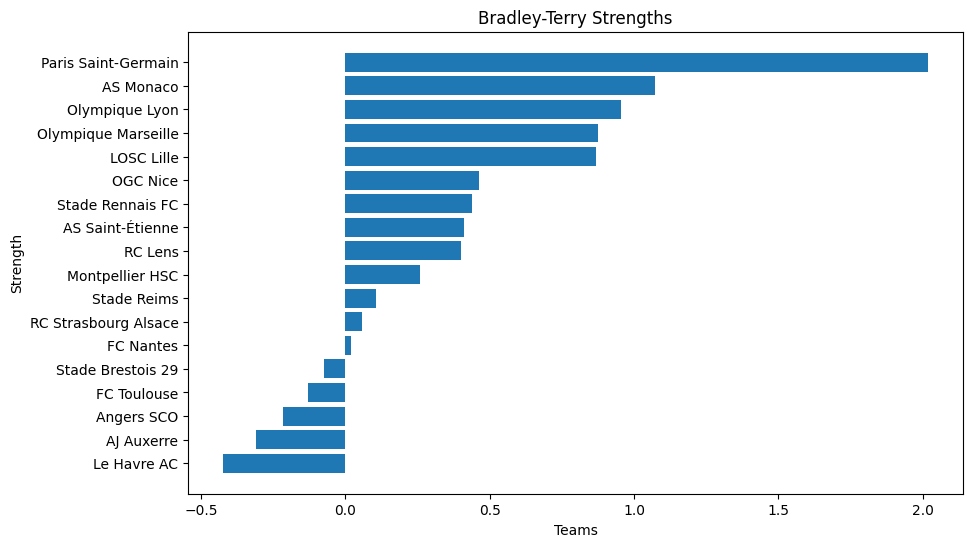

In [8]:
Evaluate.plot_strengths('BT')

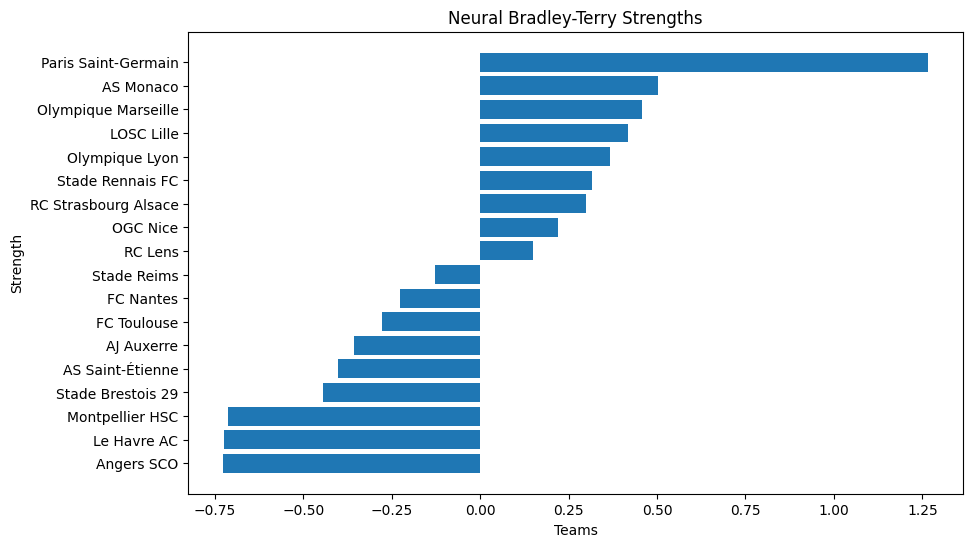

In [9]:
Evaluate.plot_strengths('NBTR')

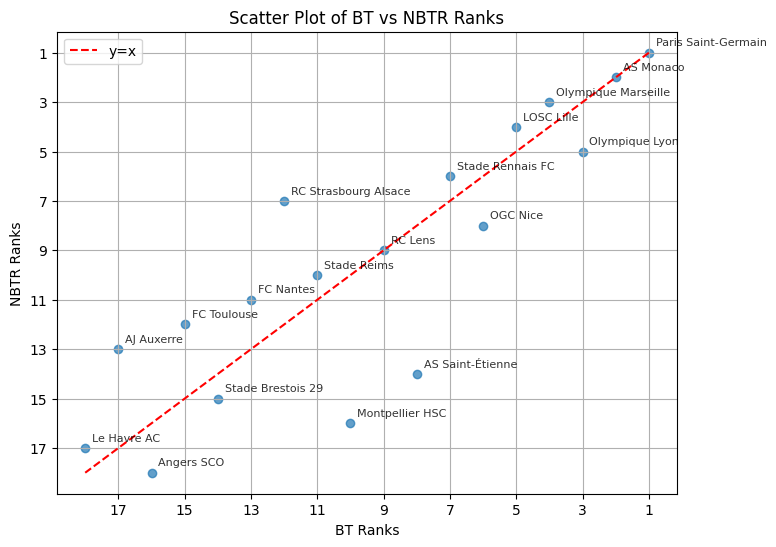

In [10]:
Evaluate.plot_scatter_ranks()

Then we look at correlation between models.

In [11]:
# Pearson correlation
print("Pearson correlation:", Evaluate.pearson_correlation())

# Spearman correlation
print("Spearman correlation:", Evaluate.spearman_correlation())

Pearson correlation: {'correlation': np.float64(0.8738617355925088), 'pvalue': np.float64(2.153415649037676e-06), 'ci_lower': np.float64(0.6464482834551808), 'ci_upper': np.float64(0.9689848945897371)}
Spearman correlation: {'correlation': np.float64(0.8513931888544891), 'pvalue': np.float64(7.42168762562196e-06), 'ci_lower': np.float64(0.5729166666666667), 'ci_upper': np.float64(0.9682982736157069)}


And correlation between empirical data and each model.

In [12]:
# Results correlation for points
print("Results correlation (points, BT):", Evaluate.results_correlation('BT', 'points'))
print("Results correlation (points, NBTR):", Evaluate.results_correlation('NBTR', 'points'))

# Results correlation for winrate
print("\nResults correlation (winrate, BT):", Evaluate.results_correlation('BT', 'winrate'))
print("Results correlation (winrate, NBTR):", Evaluate.results_correlation('NBTR', 'winrate'))

# Results correlation for adjusted winrate
print("\nResults correlation (adjusted winrate, BT):", Evaluate.results_correlation('BT', 'adjusted_winrate'))
print("Results correlation (adjusted winrate, NBTR):", Evaluate.results_correlation('NBTR', 'adjusted_winrate'))

Results correlation (points, BT): {'correlation': np.float64(0.6390913358878553), 'pvalue': np.float64(0.004299097971605389), 'ci_lower': np.float64(0.21017405144701617), 'ci_upper': np.float64(0.8721226645419271)}
Results correlation (points, NBTR): {'correlation': np.float64(0.8159272880509998), 'pvalue': np.float64(3.653488075840111e-05), 'ci_lower': np.float64(0.5333555596369288), 'ci_upper': np.float64(0.9433891096026743)}

Results correlation (winrate, BT): {'correlation': np.float64(0.6829379562335968), 'pvalue': np.float64(0.0017862357741969576), 'ci_lower': np.float64(0.2579072017494727), 'ci_upper': np.float64(0.89947147453682)}
Results correlation (winrate, NBTR): {'correlation': np.float64(0.8189028077025955), 'pvalue': np.float64(3.2391339412763576e-05), 'ci_lower': np.float64(0.49266146408093925), 'ci_upper': np.float64(0.944789448316696)}

Results correlation (adjusted winrate, BT): {'correlation': np.float64(0.6345786295225216), 'pvalue': np.float64(0.004671044394066625

#### 4.2 Match Level Comparison

In [13]:
from Test.test_BT_classical import BT_evaluate_probas

Evaluate_probas = BT_evaluate_probas(BT_results=BT_probas, NBTR_results=NBTR_probas, test_df=test_df)

We first compute the log-Loss of each model. The fewer the better.

A naive baseline (Uniform proba of win, draw, lose) gives a log-Loss of $ln(3) \approx 1,10$.

In [14]:
# log-Loss
print("Log-loss BT:", Evaluate_probas.logloss('BT'))
print("Log-loss NBTR:", Evaluate_probas.logloss('NBTR'))

Log-loss BT: 1.005558437525326
Log-loss NBTR: 0.9717659028932774


Next we compute accuracy, precision and recall to know if models correctly identifies each possible match outcome.

In [16]:
# Accuracy
print("Accuracy BT:", Evaluate_probas.accuracy('BT'))
print("Accuracy NBTR:", Evaluate_probas.accuracy('NBTR'))

# Precision
print("Precision BT:", Evaluate_probas.precision('BT'))
print("Precision NBTR:", Evaluate_probas.precision('NBTR'))

# Recall
print("Recall BT:", Evaluate_probas.recall('BT'))
print("Recall NBTR:", Evaluate_probas.recall('NBTR'))

Accuracy BT: 0.5228758169934641
Accuracy NBTR: 0.5392156862745098
Precision BT: {'H': np.float64(0.6013071895424836), 'D': 0.0, 'A': np.float64(0.4444444444444444)}
Precision NBTR: {'H': np.float64(0.6143790849673203), 'D': 0.0, 'A': np.float64(0.46405228758169936)}
Recall BT: {'H': np.float64(0.6433566433566433), 'D': np.float64(0.0), 'A': np.float64(0.6732673267326733)}
Recall NBTR: {'H': np.float64(0.6573426573426573), 'D': np.float64(0.0), 'A': np.float64(0.7029702970297029)}


#### 4.3 Stability Analysis

In [ ]:
from Neural_Bradley_Terry.stability_analysis import NBTR_Stability

Stability_tester = NBTR_Stability(train_df=train_df, test_df=test_df,
                                  feature_names=feature_names, nb_seed=10)

In [ ]:
Stability_tester.run_analysis()

## 5. NBTR Generalization to unseen teams

On this section we focus on the capacity of NBTR to estimate strength of teams for which there is no match histoty in the data.

In [17]:
from Data.data_processing import DataProcesser

processer_gen = DataProcesser("Data/Datasets/Complete_df.csv")

# Splitted Dataframes
train_df_gen, test_df_gen = processer_gen.split_train_test(test_season='25-26')

feature_names = [
    'Log_Market_Value',     
    'Strength_Rank_Based',   
    'Pythagorean_Exp',       
    'Avg_Goals_Scored',      
    'Home_Dependency',
    'Avg_Shots_Target',  
    'Avg_Corners',       
    'Avg_Cards'        
    ]

train_data_NBTR_gen = processer_gen.get_data_NBTR(feature_names=feature_names)

In [ ]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry

NBTR_model_gen = NeuralBradleyTerry(input_dim=train_data_NBTR_gen['input_dim'], hidden_dim=16, lr=0.001)

NBTR_model_gen.fit(train_data_NBTR_gen['X_home'], train_data_NBTR_gen['X_away'], train_data_NBTR_gen['y'], epochs=500)

# Vector of strengths (DataFrame)
NBTR_strength_gen = NBTR_model_gen.get_season_ranking(test_df=test_df_gen, feature_cols=feature_names)

#Outcomes probabilities for each match on the test set (DataFrame)
NBTR_probas_gen = NBTR_model_gen.predict_season_probas(test_df=test_df_gen, feature_cols=feature_names)

In [ ]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate_gen = BT_evaluate_strengths(BT_results=None, NBTR_results=NBTR_strength_gen, test_df=test_df_gen)

In [ ]:
Evaluate_gen.plot_strengths('NBTR')

In [ ]:
# Results correlation for points
print("Results correlation (points, NBTR):", Evaluate_gen.results_correlation('NBTR', 'points'))

# Results correlation for winrate
print("Results correlation (winrate, NBTR):", Evaluate_gen.results_correlation('NBTR', 'winrate'))

# Results correlation for adjusted winrate
print("Results correlation (adjusted winrate, NBTR):", Evaluate_gen.results_correlation('NBTR', 'adjusted_winrate'))

In [ ]:
from Test.test_BT_classical import BT_evaluate_probas

Evaluate_proba_gen = BT_evaluate_probas(BT_results=None, NBTR_results=NBTR_probas_gen, test_df=test_df_gen)

In [ ]:
Evaluate_proba_gen.results

In [ ]:
# Log-Loss
print("Log-loss NBTR:", Evaluate_proba_gen.logloss('NBTR'))

# Accuracy
print("Accuracy NBTR:", Evaluate_proba_gen.accuracy('NBTR'))

# Precision
print("Precision NBTR:", Evaluate_proba_gen.precision('NBTR'))

# Recall
print("Recall NBTR:", Evaluate_proba_gen.recall('NBTR'))

In [ ]:
from Neural_Bradley_Terry.NeuralBT import NeuralBradleyTerry

NBTR_model_gen_season = NeuralBradleyTerry(input_dim=train_data_NBTR_gen['input_dim'], hidden_dim=16, lr=0.001)

NBTR_model_gen_season.fit_seasons(train_data_NBTR_gen['X_home'], train_data_NBTR_gen['X_away'], train_data_NBTR_gen['y'], train_data_NBTR_gen['seasons'], epochs=500)

# Vector of strengths (DataFrame)
NBTR_strength_gen_season = NBTR_model_gen_season.get_season_ranking(test_df=test_df_gen, feature_cols=feature_names)

#Outcomes probabilities for each match on the test set (DataFrame)
NBTR_probas_gen_season = NBTR_model_gen_season.predict_season_probas(test_df=test_df_gen, feature_cols=feature_names, home_advantage=0.3)

In [ ]:
from Test.test_BT_classical import BT_evaluate_strengths

Evaluate_gen_season = BT_evaluate_strengths(BT_results=None, NBTR_results=NBTR_strength_gen_season, test_df=test_df_gen)

Evaluate_gen_season.plot_strengths('NBTR')

# Results correlation for points
print("Results correlation (points, NBTR Season):", Evaluate_gen_season.results_correlation('NBTR', 'points'))

# Results correlation for winrate
print("Results correlation (winrate, NBTR Season):", Evaluate_gen_season.results_correlation('NBTR', 'winrate'))

# Results correlation for adjusted winrate
print("Results correlation (adjusted winrate, NBTR Season):", Evaluate_gen_season.results_correlation('NBTR', 'adjusted_winrate'))

from Test.test_BT_classical import BT_evaluate_probas

Evaluate_proba_gen_season = BT_evaluate_probas(BT_results=None, NBTR_results=NBTR_probas_gen_season, test_df=test_df_gen)
# Log-Loss
print("Log-loss NBTR Season:", Evaluate_proba_gen_season.logloss('NBTR'))

# Accuracy
print("Accuracy NBTR Season:", Evaluate_proba_gen_season.accuracy('NBTR'))

# Precision
print("Precision NBTR Season:", Evaluate_proba_gen_season.precision('NBTR'))

# Recall
print("Recall NBTR Season:", Evaluate_proba_gen_season.recall('NBTR'))

In [ ]:
import numpy as np
list_ha = np.linspace(0,1,100)

list_logloss = []

for home_adv in list_ha:
    NBTR_prob = NBTR_model_gen_season.predict_season_probas(test_df=test_df_gen, feature_cols=feature_names, home_advantage=home_adv)

    Eval = BT_evaluate_probas(BT_results=None, NBTR_results=NBTR_prob, test_df=train_df_gen)
    # Log-Loss
    list_logloss.append(Eval.logloss('NBTR'))

opt_ha = list_ha[np.argmin(list_logloss)]
min_logloss = np.min(list_logloss)

import matplotlib.pyplot as plt
plt.plot(list_ha, list_logloss)
plt.axvline(x=opt_ha, color='r', linestyle='--', label=f'Optimal HA: {opt_ha:.2f}')
plt.axhline(y=min_logloss, color='g', linestyle='--', label=f'Mimimum Log-Loss: {min_logloss:.4f}')
plt.legend()
plt.xlabel("Home Advantage")
plt.ylabel("Log-Loss")
plt.title("Log-Loss vs Home Advantage for NBTR Model")
plt.show()
    